# AM-FDTD mosaic inverse design — transferring AM-FEM onto Tidy3D autograd

Reproduction of the design method in Fujisawa *et al.*, **"Mosaic-based waveguide lenses designed by the adjoint
method based on the finite-element scheme"**, Opt. Express **34**(2), 2047 (2026) — see
[`docs/oe-34-2-2047.md`](../docs/oe-34-2-2047.md) — but with **Tidy3D autograd (AM-FDTD)** as the solver instead
of frequency-domain FEM.

The device is left exactly as the upstream
[Autograd3InverseDesign](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd3InverseDesign/) example
has it: 2D, $\lambda = 1.0$, $\varepsilon_{wg} = 2.75$, a $5.0 \times 3.0$ µm design region, injecting the
fundamental mode and maximizing power into `mode_index_out = 2` (the TE$_0 \rightarrow$ TE$_1$ mode converter).
**Only the parameterization changes.** Polarization rotation is a later phase and is not attempted here.

## What transfers, and what does not

**Transfers 1:1 — the parameterization (paper §2.2, Eqs. 4–6).** One design variable $\rho \in [0,1]$ per
100 nm pixel, mapped to permittivity through a power-law Heaviside $H(\rho)$ whose sharpness $m$ is ramped
2 → 64. No spatial filter and no minimum-feature penalty, because — as the paper puts it in §1 — *"the
manufacturable pixel size is set from the beginning."*

**Replaced wholesale — the adjoint machinery (paper Eqs. 7–13).** Those equations hand-derive the gradient
through the FEM matrix $[P]$: assembling $\partial[P]/\partial\varepsilon$, solving for the adjoint vector
$\{\lambda_{out}\}$, and contracting to $\partial F/\partial\varepsilon$. **None of it is ported.** Tidy3D's
`value_and_grad` runs the adjoint FDTD simulation and does all of it automatically. Eq. (14)'s plain gradient
descent is likewise replaced by Adam. So the whole of §2.2 collapses to Eqs. (4)–(6) plus one `value_and_grad`.

**Does not transfer — solver asymmetries, in both directions.**

1. *FEM's multi-port advantage is lost.* The paper notes that one LU factorization of $[P]$ serves every input
   condition, calling this "the advantage of frequency-domain analysis to time-domain analysis, such as FDTD."
   In FDTD **each input mode needs its own forward simulation**. Our objective is single-input/single-output-mode
   so this costs us nothing here, but it is why the method will not scale to multi-port objectives as cheaply.
2. *FDTD wins on wavelengths.* The paper's $N_\lambda = 3$ needs three separate FEM solves; in FDTD one
   broadband pulse yields all frequencies from a **single** simulation. Multi-wavelength objectives are nearly
   free here. This notebook still keeps the upstream single-frequency objective.

In [24]:
from typing import List

import autograd.numpy as anp
import matplotlib.pylab as plt
import numpy as np

# import regular tidy3d
import tidy3d as td
import tidy3d.web as web
from autograd import value_and_grad
from tidy3d.plugins.mode import ModeSolver

# set random seed to get same results
np.random.seed(2)

In [25]:
# Initialize live viewer for real-time visualization
from photonforge.live_viewer import LiveViewer
viewer = LiveViewer()

LiveViewer started at http://localhost:60647


## Setup

A mode source is injected into a waveguide on the left-hand side. The light propagates through a rectangular
**mosaic region** — a grid of square pixels, each of which will end up either cladding (`0`) or waveguide
material (`1`) — and we measure transmission into a higher-order mode of the waveguide on the right.

Unlike the upstream example, there is **no conic filter and no erosion/dilation penalty**. Those exist to
impose a minimum feature size on a free-form design; here the pixel *is* the minimum feature size, so they are
redundant, and a filter whose radius exceeded the pixel pitch would actively smear neighbouring pixels together.

### Parameters

The device parameters below are unchanged from the upstream example. What is added is the mosaic
discretization, in the cell after next.

In [26]:
# wavelength and frequency
wavelength = 1.0
freq0 = td.C_0 / wavelength
k0 = 2 * np.pi * freq0 / td.C_0

# resolution control
min_steps_per_wvl = 16

# space between boxes and PML
buffer = 1.0 * wavelength

# optimize region size
lz = td.inf
lx = 5.0
ly = 3.0

# position of source and monitor (constant for all)
source_x = -lx / 2 - buffer * 0.8
meas_x = lx / 2 + buffer * 0.8

# total size
Lx = lx + 2 * buffer
Ly = ly + 2 * buffer
Lz = 0.0

# permittivity and width of the input/output waveguide
eps_wg = 2.75
wg_width = 0.7

# frequency width and run time
freqw = freq0 / 10
run_time = 50 / freqw

### Mosaic discretization — two grids, not one

The upstream example sets `dl_design_region = 0.01` and defines **one parameter per FDTD cell**, giving
$500 \times 300 = 150{,}000$ free parameters. That is a free-form design.

A mosaic needs the opposite: few, coarse parameters on a manufacturable pitch. But the 100 nm pixel pitch the
paper uses is far too coarse to *simulate* on — at $\lambda/n = 1.0/1.66 = 0.60$ µm that would be 6 cells per
wavelength. So the two roles are separated:

| grid | symbol | role |
|---|---|---|
| **pixel grid** | `n_bx × n_by` at `pixel_size` | the optimization variables $\rho$ — one per pixel |
| **permittivity grid** | `nx × ny` at `dl_eps` | what the FDTD solver actually resolves |

They are linked by an **integer** ratio `k = pixel_size / dl_eps`. Each $\rho$ is stamped into a solid
$k \times k$ block before it reaches the solver, so every pixel stays perfectly uniform — that is what makes the
design *digital* rather than merely pixelated-looking.

In [27]:
# --- the two independent knobs ------------------------------------------------
pixel_size = 0.1      # "bit size": mosaic pixel edge length (um). Paper uses 100 nm.
dl_eps = 0.02         # permittivity-array / design-region FDTD resolution (um)
# ------------------------------------------------------------------------------

k = int(round(pixel_size / dl_eps))
assert abs(pixel_size / dl_eps - k) < 1e-9, "pixel_size must be an integer multiple of dl_eps"

# pixel grid: the optimization variables (rho)
n_bx = int(round(lx / pixel_size))
n_by = int(round(ly / pixel_size))
n_pixels = n_bx * n_by

# permittivity grid: what the solver sees
nx, ny = n_bx * k, n_by * k
dl_design_region = dl_eps

# paper's three uniform initial structures (Figs. 3 and 5)
rho_inits = [0.498, 0.7, 0.9]

print(f"pixel size {pixel_size} um   -> mosaic {n_bx} x {n_by} = {n_pixels} pixels")
print(f"eps resolution {dl_eps} um -> eps grid {nx} x {ny} ({k}x{k} cells per pixel)")
print(f"cells per wavelength in the guide: {wavelength / np.sqrt(eps_wg) / dl_eps:.1f}")
print(f"upstream example, for comparison:  {int(lx / 0.01) * int(ly / 0.01)} free parameters")
print(f"paper's mosaic regions, for scale: 400 to 624 pixels")

pixel size 0.1 um   -> mosaic 50 x 30 = 1500 pixels
eps resolution 0.02 um -> eps grid 250 x 150 (5x5 cells per pixel)
cells per wavelength in the guide: 30.2
upstream example, for comparison:  150000 free parameters
paper's mosaic regions, for scale: 400 to 624 pixels


### Static Components

Next, we will set up the static parts of the geometry, the input source,
and the output monitor using these parameters.

In [28]:
waveguide = td.Structure(
    geometry=td.Box(size=(2 * Lx, wg_width, lz)), medium=td.Medium(permittivity=eps_wg)
)

mode_size = (0, wg_width * 3, lz)

source_plane = td.Box(
    center=[source_x, 0, 0],
    size=mode_size,
)

measure_plane = td.Box(
    center=[meas_x, 0, 0],
    size=mode_size,
)

### Input structures — the paper's parameterization (Eqs. 4–6)

This is the heart of the transfer. The paper writes the permittivity of pixel $(i,j)$ as a continuous function
of a design variable $\rho \in [0,1]$ so that it can be differentiated, **Eq. (4)**:

$$\varepsilon_{r,ij}(\rho) = \varepsilon_{clad} + (\varepsilon_{core} - \varepsilon_{clad})\, H(\rho)$$

where $H$ is a power-law approximation to a Heaviside step, **Eq. (5)**:

$$H(\rho) = \begin{cases} 0.5\,(2\rho)^m & 0 \le \rho \le 0.5 \\ 1 - 0.5\,(2 - 2\rho)^m & 0.5 \le \rho \le 1 \end{cases}$$

$m$ is the *adjustment parameter*. Small $m$ makes $H$ vary smoothly; large $m$ makes it snap sharply around
$\rho = 0.5$, and $m \rightarrow \infty$ gives a true step. The paper ramps $m$ from 2 to 64 over the
optimization, so the design starts continuous (informative gradients) and ends essentially binary.

The paper then derives $\partial\varepsilon_r/\partial\rho$ by hand in **Eq. (6)** because AM-FEM needs it
explicitly. We do not: `autograd` differentiates `H` for us. The cell after next checks that autograd's
derivative agrees with Eq. (6) anyway, as a correctness test on the implementation.

`upsample` stamps each pixel into a $k \times k$ block. It is a Kronecker product with a block of ones, so it is
differentiable — the reverse pass simply **sums** the sub-cell gradients back onto the pixel that produced them.

In [29]:
eps_clad = 1.0        # upstream example's background is vacuum
eps_core = eps_wg

# Smallest dH/drho a pixel is allowed to have. Measured below: Adam's per-parameter
# normalisation still moves a pixel whose TOTAL gradient is 1e-8, but stalls at 1e-10 and
# below. The total is dH/drho * dJ/deps, so holding dH/drho >= 1e-6 leaves headroom for a
# small dJ/deps. Lower it for a wider rho range, raise it for more mobility; the "at rails"
# and "|grad|" columns in the optimization loop tell you which way to go.
GRAD_FLOOR = 1e-6


def H(rho, m):
    """Paper Eq.(5): power-law Heaviside approximation. m -> inf gives a step function."""
    return anp.where(rho <= 0.5, 0.5 * (2 * rho) ** m, 1 - 0.5 * (2 - 2 * rho) ** m)


def dH_drho_paper(rho, m):
    """Paper Eq.(6), for verification only -- autograd does not need this."""
    return np.where(rho <= 0.5, m * (2 * rho) ** (m - 1), m * (2 - 2 * rho) ** (m - 1))


def rho_bounds(m, delta=GRAD_FLOOR):
    """Clip range that keeps dH/drho >= delta at the rails, so no pixel can freeze.

    dH/drho = m (2 - 2 rho)^(m-1) >= delta  =>  rho <= 1 - 0.5 (delta/m)^(1/(m-1)).
    The range narrows as m grows, but H is already saturated there (H = 1.0 and 0.0 to
    machine precision), so the permittivity is unaffected -- only rho stays maneuverable.
    """
    if m <= 1.0:
        return 0.0, 1.0
    t = 0.5 * (delta / m) ** (1.0 / (m - 1.0))
    return t, 1.0 - t


def upsample(pixels, k):
    """Stamp each pixel into a solid k x k block of permittivity cells. Differentiable."""
    return anp.kron(pixels, anp.ones((k, k)))


def get_eps(rho, m):
    """Paper Eq.(4): eps_r(rho) = eps_clad + (eps_core - eps_clad) H(rho), on the eps grid."""
    return eps_clad + (eps_core - eps_clad) * upsample(H(rho, m), k)


def make_input_structures(rho, m) -> List[td.Structure]:
    box = td.Box(center=(0, 0, 0), size=(lx, ly, lz))
    eps_data = get_eps(rho, m=m).reshape((nx, ny, 1))
    custom_structure = td.Structure.from_permittivity_array(geometry=box, eps_data=eps_data)

    return [custom_structure]

In [30]:
from autograd import elementwise_grad
from tidy3d.plugins.autograd import adam, apply_updates

# 1. autograd's derivative of H must reproduce the paper's Eq.(6)
rr = np.linspace(0.0, 1.0, 20001)
for m_test in (2.0, 8.0, 64.0):
    err = np.abs(elementwise_grad(lambda x: H(x, m_test))(rr) - dH_drho_paper(rr, m_test)).max()
    assert err == 0.0, f"autograd disagrees with Eq.(6) at m={m_test}: {err}"
print("autograd d(H)/d(rho) == paper Eq.(6) exactly, for m = 2, 8, 64")

# 2. anp.where evaluates BOTH branches -- make sure the unselected one never poisons the gradient
for m_test in (2.0, 4.0, 8.0, 16.0, 32.0, 64.0):
    v, g = H(rr, m_test), elementwise_grad(lambda x: H(x, m_test))(rr)
    assert np.isfinite(v).all() and np.isfinite(g).all(), f"NaN/Inf at m={m_test}"
assert H(np.array([0.5]), 64.0)[0] == 0.5, "H(0.5) must be exactly 0.5 for any m"
print("no NaN/Inf across the whole m ramp; H(0.5) == 0.5 exactly")

# 3. How small a gradient can Adam still act on? This sets GRAD_FLOOR.
print("\ndistance a pixel travels in 20 Adam steps (lr=0.05) vs its gradient magnitude:")
for g_mag in (1e-4, 1e-6, 1e-8, 1e-10, 1e-12):
    p = np.array([0.5]); opt = adam(learning_rate=0.05); st = opt.init(p)
    for _ in range(20):
        upd, st = opt.update(np.array([-g_mag]), st, p)
        p = apply_updates(p, upd)
    move = float(p[0] - 0.5)
    print(f"   |g| = {g_mag:.0e}  ->  travel {move:>9.6f}   {'usable' if abs(move) > 0.01 else 'STUCK'}")
print("   -> Adam's per-parameter normalisation rescues small gradients, but not below ~1e-8.")

# 4. THE FROZEN-PIXEL PROBLEM, and why the clip has to depend on m.
print(f"\n{'m':>6} {'dH at rho=1':>13} {'dH at rho=0.999':>17} {'dH at rho_hi(m)':>17} {'rho range':>18}")
for m_test in (2.0, 8.0, 16.0, 32.0, 64.0):
    lo, hi = rho_bounds(m_test)
    print(f"{m_test:>6.0f} {dH_drho_paper(np.array([1.0]), m_test)[0]:>13.2e} "
          f"{dH_drho_paper(np.array([1 - 1e-3]), m_test)[0]:>17.2e} "
          f"{dH_drho_paper(np.array([hi]), m_test)[0]:>17.2e}   [{lo:.3f}, {hi:.3f}]")
print("  -> rho=1 is dead for every m. A FIXED inset like 0.999 is also dead from m~16 on,")
print("     since (0.002)^(m-1) underflows. Only the m-dependent bound holds the floor.")

# and it costs nothing: the permittivity is already saturated at those bounds
for m_test in (8.0, 64.0):
    lo, hi = rho_bounds(m_test)
    e_hi = eps_clad + (eps_core - eps_clad) * H(np.array([hi]), m_test)[0]
    e_lo = eps_clad + (eps_core - eps_clad) * H(np.array([lo]), m_test)[0]
    print(f"     m={m_test:>5.1f}: eps(rho_hi) = {e_hi:.6f} (core = {eps_core})   "
          f"eps(rho_lo) = {e_lo:.6f} (clad = {eps_clad})")
print("     -> narrowing rho costs no permittivity contrast; it only keeps pixels mobile.")

# 5. what the m ramp actually does: it concentrates gradient near the decision boundary
print("\nfraction of gradient mass in rho in (0.4, 0.6):")
for m_test in (2, 8, 32, 64):
    g = dH_drho_paper(rr, m_test); g = g / g.sum()
    print(f"   m={m_test:>2}: {g[(rr > 0.4) & (rr < 0.6)].sum() * 100:>5.1f}%")
print("   -> decided pixels settle, undecided ones keep moving. That IS the binarization.")

autograd d(H)/d(rho) == paper Eq.(6) exactly, for m = 2, 8, 64
no NaN/Inf across the whole m ramp; H(0.5) == 0.5 exactly

distance a pixel travels in 20 Adam steps (lr=0.05) vs its gradient magnitude:
   |g| = 1e-04  ->  travel  0.999900   usable
   |g| = 1e-06  ->  travel  0.990099   usable
   |g| = 1e-08  ->  travel  0.500000   usable
   |g| = 1e-10  ->  travel  0.009901   STUCK
   |g| = 1e-12  ->  travel  0.000100   STUCK
   -> Adam's per-parameter normalisation rescues small gradients, but not below ~1e-8.

     m   dH at rho=1   dH at rho=0.999   dH at rho_hi(m)          rho range
     2      0.00e+00          4.00e-03          1.00e-06   [0.000, 1.000]
     8      0.00e+00          1.02e-18          1.00e-06   [0.052, 0.948]
    16      0.00e+00          5.24e-40          1.00e-06   [0.165, 0.835]
    32      0.00e+00          6.87e-83          1.00e-06   [0.286, 0.714]
    64      0.00e+00         5.90e-169          1.00e-06   [0.376, 0.624]
  -> rho=1 is dead for every m. A FIX

### Making the Simulation

Next, we write a function to return a basic `td.Simulation` as a
function of our parameter values.

We make sure to add the pixelated `td.Structure` list to
`input_structures` but leave out the sources and monitors for now as
we’ll want to add those after the mode solver is run so we can inspect
them.

In [31]:
def make_sim_base(rho: np.ndarray, m: float) -> td.Simulation:
    """Create the simulation given the pixel values rho and the sharpness m."""

    structures = make_input_structures(rho, m=m)
    design_region_mesh = td.MeshOverrideStructure(
        geometry=td.Box(size=(lx, ly, lz)),
        dl=[dl_design_region] * 3,
        enforce=True,
    )
    grid_spec = td.GridSpec.auto(
        wavelength=wavelength,
        min_steps_per_wvl=16,
        override_structures=[design_region_mesh],
    )

    return td.Simulation(
        size=[Lx, Ly, Lz],
        grid_spec=grid_spec,
        structures=[waveguide] + structures,
        sources=[],
        monitors=[],
        run_time=run_time,
        boundary_spec=td.BoundarySpec.pml(x=True, y=True, z=False),
    )

### Visualize

Let’s visualize the simulation to see how it looks

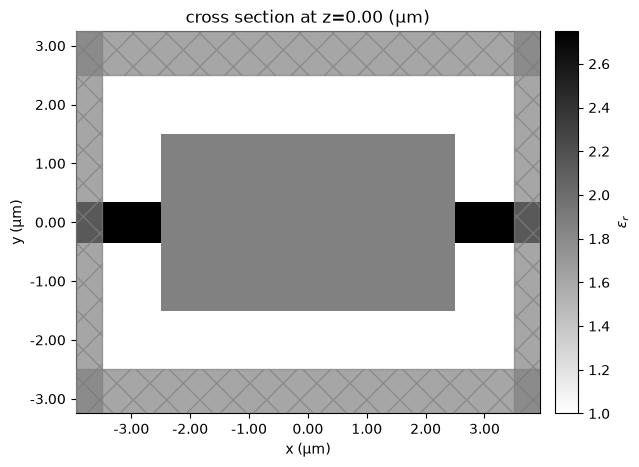

In [32]:
# the paper's lowest-FOM initial structure: uniform rho, NOT random
rho0 = np.full((n_bx, n_by), rho_inits[0])

sim_start = make_sim_base(rho0, m=2.0)

ax = sim_start.plot_eps(z=0, freq=freq0)

plt.show()

### Select Input and Output Modes

Next, let’s visualize the first 4 mode profiles so we can select which
mode indices we want to inject and transmit.

In [33]:
from tidy3d.plugins.mode.web import run as run_mode_solver

num_modes = 4
mode_spec = td.ModeSpec(num_modes=num_modes)

mode_solver = ModeSolver(
    simulation=sim_start,
    plane=source_plane,
    mode_spec=td.ModeSpec(num_modes=num_modes),
    freqs=[freq0],
)
modes = run_mode_solver(mode_solver, reduce_simulation=True)

16:03:48 SE Asia Standard Time Mode solver created with                         
                               task_id='fdve-1301e69c-68e3-45aa-9527-fd6df419014
                               9',                                              
                               solver_id='mo-23ceef72-c7db-4da0-8a58-cb18e95360e
                               9'.

Output()

Output()

16:03:55 SE Asia Standard Time Mode solver status: success

Output()

Let’s visualize the modes next.

Effective index of computed modes:  [[1.57199487 1.53558055 1.30320163 1.18556448]]


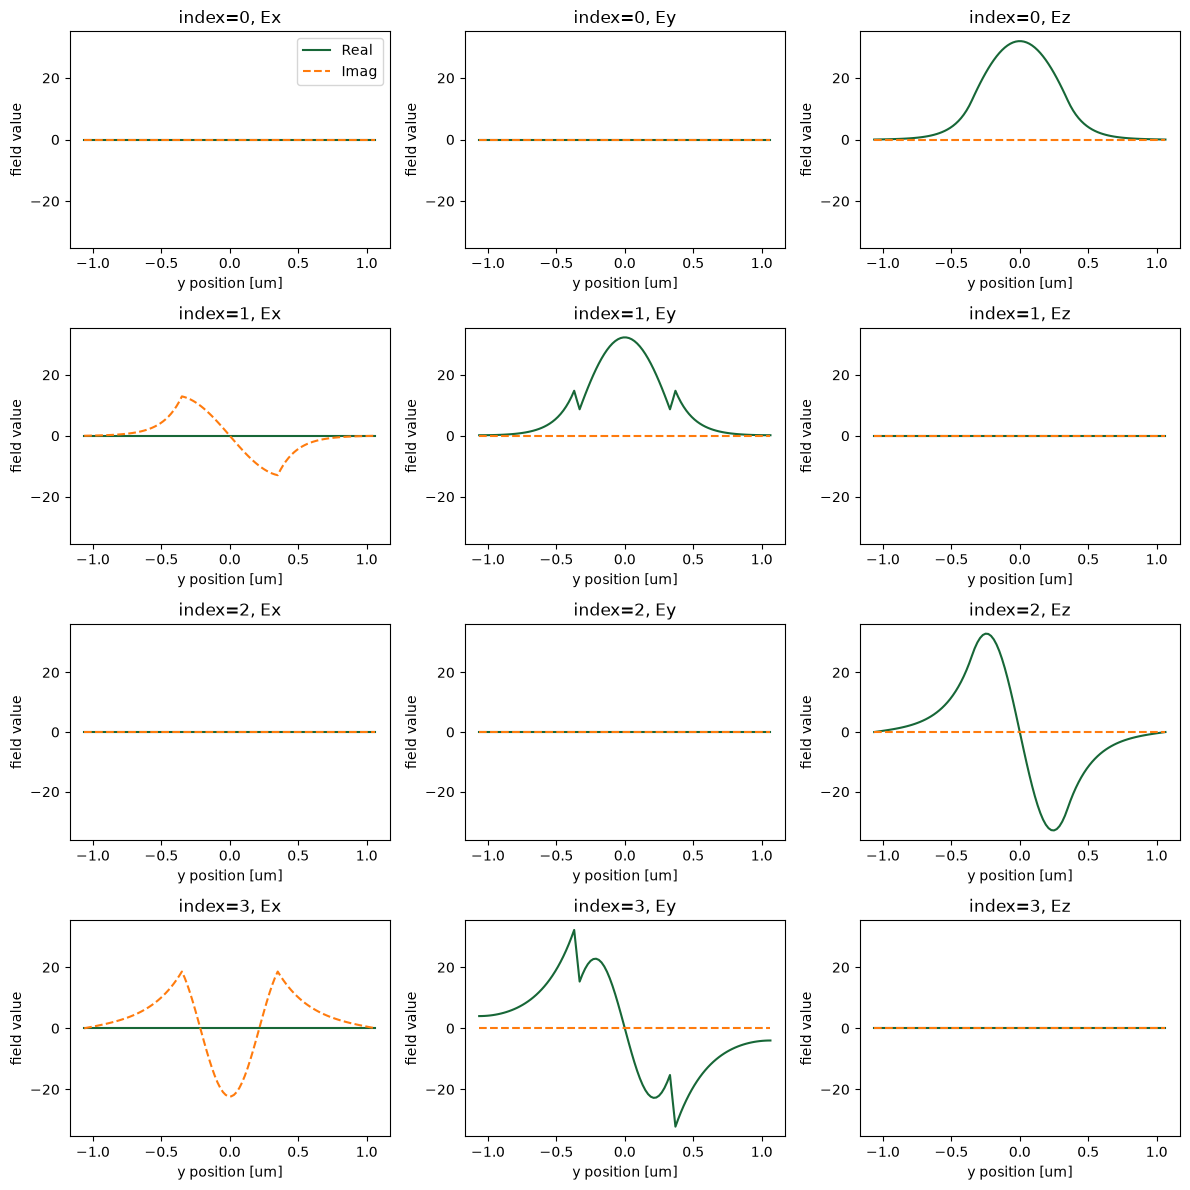

In [34]:
fig, axs = plt.subplots(num_modes, 3, figsize=(12, 12), tight_layout=True)
for mode_index in range(num_modes):
    vmax = 1.1 * max(
        abs(modes.field_components[n].sel(mode_index=mode_index)).max() for n in ("Ex", "Ey", "Ez")
    )
    for field_name, ax in zip(("Ex", "Ey", "Ez"), axs[mode_index]):
        field = modes.field_components[field_name].sel(mode_index=mode_index)
        field.real.plot(label="Real", ax=ax)
        field.imag.plot(ls="--", label="Imag", ax=ax)
        ax.set_title(f"index={mode_index}, {field_name}")
        ax.set_ylim(-vmax, vmax)

axs[0, 0].legend()

print("Effective index of computed modes: ", np.array(modes.n_eff))

We want to inject the fundamental, Ez-polarized input into the 1st order
Ez-polarized input.

From the plots, we see that these modes correspond to the first and
third rows, or `mode_index=0` and `mode_index=2`, respectively.

So we make sure that the `mode_index_in` and `mode_index_out` variables
are set appropriately and we set a `ModeSpec` with 3 modes to be able to
capture the `mode_index_out` in our output data.

In [35]:
mode_index_in = 0
mode_index_out = 2

num_modes = max(mode_index_in, mode_index_out) + 1

mode_spec = td.ModeSpec(num_modes=num_modes)

Then it is straightforward to generate our source and monitor.

In [36]:
# source seeding the simulation
forward_source = td.ModeSource(
    source_time=td.GaussianPulse(freq0=freq0, fwidth=freqw),
    center=[source_x, 0, 0],
    size=mode_size,
    mode_index=mode_index_in,
    mode_spec=mode_spec,
    direction="+",
)

# we'll refer to the measurement monitor by this name often
measurement_monitor_name = "measurement"

# monitor where we compute the objective function from
measurement_monitor = td.ModeMonitor(
    center=[meas_x, 0, 0],
    size=mode_size,
    freqs=[freq0],
    mode_spec=mode_spec,
    name=measurement_monitor_name,
)

Finally, we create a new function that calls our `make_sim_base()`
function and adds the source and monitor to the result. This is the
function we will use in our objective function to generate our
`td.Simulation` given the input parameters.

In [37]:
def make_sim(rho, m):
    sim = make_sim_base(rho, m=m)
    return sim.updated_copy(sources=[forward_source], monitors=[measurement_monitor])

eps array shape: (250, 150)  expected: (250, 150)
eps range: 1.000 .. 2.750  (eps_clad = 1.0, eps_core = 2.75)
max spread within a pixel: 0.0  -> every pixel is a solid block


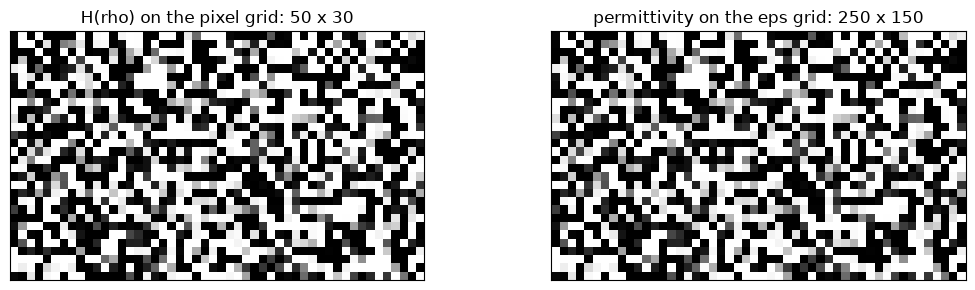

In [38]:
# Check the two grids line up and that a pixel really is one solid block.
_probe = np.random.default_rng(0).random((n_bx, n_by))
_eps = get_eps(_probe, m=8.0)

print("eps array shape:", _eps.shape, " expected:", (nx, ny))
print(f"eps range: {_eps.min():.3f} .. {_eps.max():.3f}  (eps_clad = {eps_clad}, eps_core = {eps_core})")

# every k x k block must be perfectly uniform -- this is what makes the design "digital"
_blocks = _eps.reshape(n_bx, k, n_by, k)
spread = np.abs(_blocks - _blocks[:, :1, :, :1]).max()
assert spread == 0.0, f"pixels are not uniform blocks (spread {spread})"
print(f"max spread within a pixel: {spread}  -> every pixel is a solid block")

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 3), tight_layout=True)
a0.imshow(np.flipud(H(_probe, 8.0).T), cmap="gray_r", interpolation="nearest")
a0.set_title(f"H(rho) on the pixel grid: {n_bx} x {n_by}")
a1.imshow(np.flipud(_eps.T), cmap="gray_r", interpolation="nearest")
a1.set_title(f"permittivity on the eps grid: {nx} x {ny}")
for a in (a0, a1):
    a.set_xticks([]); a.set_yticks([])
plt.show()

### Post Processing

Next, we will define a function to tell us how we want to postprocess
the output `td.SimulationData` object to give the conversion power that
we are interested in maximizing.

In [39]:
def measure_power(sim_data: td.SimulationData) -> float:
    """Return the power in the output_data amplitude at the mode index of interest."""
    output_amps = sim_data["measurement"].amps
    amp = output_amps.sel(direction="+", f=freq0, mode_index=mode_index_out).values
    return anp.sum(anp.abs(amp) ** 2)

The upstream example adds an erosion/dilation penalty here to enforce a minimum length scale. **We drop it**,
along with the conic filter, for the reason the paper gives in §1: on a mosaic the manufacturable pixel size is
set from the beginning, so there is nothing left for a length-scale penalty to enforce.

### Define Objective Function

Finally, we need to define the objective function that we want to
maximize as a function of our input parameters (permittivity of each
pixel) that returns the conversion power. This is the function we will
differentiate later.

In [40]:
from tidy3d.plugins.autograd import grey_indicator, make_erosion_dilation_penalty

# Erosion/dilation penalty, evaluated on the PIXEL lattice (50 x 30) -- not the eps grid, and not
# at the upstream example's physical radius of 0.120 um.
#
# Why it is here at all. The 100 nm pixel forbids features *thinner* than one pixel, but it does
# not forbid features exactly one pixel thin, and the previous run walked straight into that gap:
# it filled the design with 1-px stripes running along the propagation direction. That is a
# form-birefringent effective medium (period ~0.1-0.2 um against lambda/n ~ 0.6 um), not a mosaic.
# Relaxed J looked excellent because stripe duty cycle synthesises any effective index you like;
# under hard thresholding a duty cycle of 0.6 snaps to 0 or 1 and the synthesised index collapses.
#
# A binarization penalty cannot see this, because the stripes are perfectly binary. Measured on
# this lattice: 1-px lamination -> ED = 1.000, grey_indicator = 0.000; healthy blob -> ED = 0.001.
# ED also scores ~1.0 on a uniform gray design, so it covers grayness too and a separate grey term
# would be redundant. grey_indicator is kept below as a free diagnostic only.
#
# radius is in PIXELS here (dl = 1.0). radius=1.0 gives a 3x3 conic kernel whose off-centre weights
# are all zero -- it collapses to the identity and the penalty is then identically zero for every
# input. 1.5 px (a 5x5 kernel) is the smallest usable value.
PENALTY_RADIUS_PX = 1.5

penalty = make_erosion_dilation_penalty(radius=PENALTY_RADIUS_PX, dl=1.0)


# The two halves of the objective are computed separately, for a reason that only shows up when
# you measure it. A FIXED penalty weight does not work here, because the penalty's gradient and
# the physics gradient live on completely different scales, and the ratio moves by orders of
# magnitude during the run:
#
#   rho state                          |grad(ED . H)|     physics |grad| (previous run)
#   uniform start (rho = 0.498)            1.6e-08                  ~5e-07
#   mid-run, rho spread across the band    1.8e-02                  ~0.35
#   fully laminated, pixels at the rails   2.3e-15                  ~0.35
#
# At the rails the chain rule multiplies ED's gradient by dH/drho, which rho_bounds pins at
# GRAD_FLOOR = 1e-6, so the penalty goes numerically dead exactly where the damage is already
# done. The penalty can PREVENT lamination; it cannot UNDO it. A fixed weight tuned for one of
# those regimes is meaningless in the other two.
#
# So the weight is set in RELATIVE terms instead: each step the penalty gradient is rescaled to
# carry W_REL of the physics gradient's norm. That is scale-free, needs no tuning against an
# unknown physics gradient magnitude, and degrades safely -- if the penalty gradient vanishes, its
# contribution goes to zero rather than exploding.
W_REL = 0.25       # penalty gradient norm as a fraction of the physics gradient norm
W_SAT_STEP = 4     # iteration at which W_REL is reached


def w_of(i):
    """Relative penalty strength vs iteration index (0-based). Ramps on ITERATION, not on m.

    Deliberately decoupled from the m ramp. The anti-lamination pressure has to land while the
    topology can still reorganise, and the linear m ramp stiffens early -- the rho band is already
    down to 0.78 by step 4. So the weight saturates there and then holds constant, which leaves the
    late high-m steps stiffening for one reason instead of two.
    """
    return W_REL * min(1.0, (i + 1) / W_SAT_STEP)


def J_power(rho: np.ndarray, m: float, step_num=None, verbose: bool = False) -> float:
    """Converted power into mode_index_out. This is the half that costs an FDTD forward+adjoint."""
    sim = make_sim(rho, m=m)
    task_name = "mosaic_amfdtd"
    if step_num:
        task_name += f"_step_{step_num}"
    sim_data = web.run(sim, task_name=task_name, verbose=verbose)
    return measure_power(sim_data)


def J_penalty(rho: np.ndarray, m: float) -> float:
    """Erosion/dilation penalty on the projected pixel densities. Pure numpy -- free."""
    return penalty(H(rho, m))


def combine(power, g_power, ed, g_ed, w_rel):
    """Balance the two gradients, then report the objective they correspond to.

    Returns (J, gradient, scale). `scale` is the absolute penalty weight this step worked out to,
    printed in the loop so the balance is visible rather than assumed.
    """
    n_p, n_e = np.linalg.norm(g_power), np.linalg.norm(g_ed)
    scale = w_rel * n_p / n_e if n_e > 1e-12 else 0.0
    return power - scale * ed, g_power - scale * g_ed, scale


def fom(power):
    """The paper MINIMIZES a fitness function of the form |1 - T| (Eqs. 15-17); we maximize power
    internally. This derived quantity exists only so the convergence plot reads like the paper's."""
    return np.abs(1.0 - np.asarray(power))


In [41]:
from autograd import grad as _agrad

# Offline self-tests for the penalty -- no simulation, no credits.
#
# The penalty is only useful if it separates the failure mode from a healthy design, and the
# radius has a trap in it (see the note above), so check both before spending anything.
_lam = np.zeros((n_bx, n_by))
_lam[:, ::2] = 1.0                       # 1-px lamination: the previous run's failure mode
_blob = np.zeros((n_bx, n_by))
_blob[10:40, 8:22] = 1.0                 # a healthy, connected feature
_checker = (np.indices((n_bx, n_by)).sum(0) % 2).astype(float)
_gray = np.full((n_bx, n_by), 0.5)

print(f"{'pattern':<22}{'ED':>9}{'grey':>9}")
for _name, _p in [("1-px lamination", _lam), ("checkerboard", _checker),
                  ("healthy blob", _blob), ("uniform gray", _gray)]:
    print(f"{_name:<22}{float(penalty(_p)):>9.4f}{float(grey_indicator(_p)):>9.4f}")

assert float(penalty(_lam)) > 0.9, "penalty is blind to lamination -- check PENALTY_RADIUS_PX"
assert float(penalty(_checker)) > 0.9, "penalty is blind to checkerboarding"
assert float(penalty(_blob)) < 0.01, "penalty is taxing healthy features too hard"
assert float(grey_indicator(_lam)) < 1e-9, "grey_indicator should be blind here -- that is the point"

# it must also be finite and differentiable through H at every m on the ramp
for _m in (2.0, 8.0, 16.0, 32.0, 64.0):
    _lo, _hi = rho_bounds(_m)
    _r = np.clip(np.random.default_rng(0).random((n_bx, n_by)), _lo, _hi)
    _v = J_penalty(_r, _m)
    _g = _agrad(lambda x: J_penalty(x, _m))(_r)
    assert np.isfinite(float(_v)), f"penalty not finite at m={_m}"
    assert _g.shape == (n_bx, n_by) and np.isfinite(_g).all(), f"penalty gradient bad at m={_m}"
print("\npenalty is finite and differentiable on the pixel grid across the whole m ramp")

# The regime table quoted in the objective cell, reproduced here so it stays honest if anything
# above is edited. The rails row is the one that matters: the penalty goes dead there.
print(f"\n{'rho state':<38}{'|grad(ED.H)|':>14}")
_rng = np.random.default_rng(1)
for _name, _r, _m in [
    ("uniform start (rho=0.498)", np.full((n_bx, n_by), 0.498), 2.0),
    ("mid-run, spread across the band", np.clip(_rng.normal(0.5, 0.12, (n_bx, n_by)), 0.29, 0.71), 37.9),
    ("fully laminated, pixels at rails", None, 64.0),
]:
    if _r is None:
        _lo, _hi = rho_bounds(_m)
        _r = np.full((n_bx, n_by), _lo); _r[:, ::2] = _hi
    print(f"{_name:<38}{np.linalg.norm(_agrad(lambda x: J_penalty(x, _m))(_r)):>14.2e}")
print("  -> the penalty PREVENTS lamination; it cannot UNDO it once pixels sit at the rails.")

# combine() must degrade safely when the penalty gradient vanishes, rather than exploding
_gp = np.ones((n_bx, n_by))
_Jv, _gv, _sc = combine(0.9, _gp, 1.0, np.zeros((n_bx, n_by)), 0.25)
assert _sc == 0.0 and np.allclose(_gv, _gp), "combine() must no-op on a dead penalty gradient"
_Jv, _gv, _sc = combine(0.9, _gp, 1.0, _gp.copy(), 0.25)
assert abs(np.linalg.norm(_sc * _gp) / np.linalg.norm(_gp) - 0.25) < 1e-12, "W_REL not honoured"
print("\ncombine(): penalty gradient carries exactly W_REL of the physics norm, and no-ops if dead")

print("\nw_rel(i) over the run:", " ".join(f"{w_of(_i):.3f}" for _i in range(20)))


pattern                      ED     grey
1-px lamination          1.0000   0.0000
checkerboard             1.0000   0.0000
healthy blob             0.0014   0.0000
uniform gray             1.0000   1.0000

penalty is finite and differentiable on the pixel grid across the whole m ramp

rho state                               |grad(ED.H)|
uniform start (rho=0.498)                   5.49e-08
mid-run, spread across the band             2.45e-01
fully laminated, pixels at rails            7.54e-15
  -> the penalty PREVENTS lamination; it cannot UNDO it once pixels sit at the rails.

combine(): penalty gradient carries exactly W_REL of the physics norm, and no-ops if dead

w_rel(i) over the run: 0.062 0.125 0.188 0.250 0.250 0.250 0.250 0.250 0.250 0.250 0.250 0.250 0.250 0.250 0.250 0.250 0.250 0.250 0.250 0.250


## Inverse Design

Now we are ready to perform the optimization.

We use the `autograd.value_and_grad` function to get the gradient of `J`
with respect to the permittivity of each `Box`, while also returning the
converted power associated with the current iteration, so we can record
this value for later.

Let’s try running this function once to make sure it works.

In [42]:
dJ_power = value_and_grad(J_power)      # costs one FDTD forward + one adjoint
dJ_penalty = value_and_grad(J_penalty)  # pure numpy, no simulation


In [43]:
power, g_power = dJ_power(rho0, m=2.0, verbose=True)
ed, g_ed = dJ_penalty(rho0, m=2.0)
value, gradient, scale = combine(power, g_power, ed, g_ed, w_of(0))

print(f"\npower   = {power:.4e}   |grad| = {np.linalg.norm(g_power):.4e}")
print(f"ED      = {ed:.4f}       |grad| = {np.linalg.norm(g_ed):.4e}")
print(f"scale   = {scale:.4e}   (w_rel = {w_of(0):.3f})")
print(f"J       = {value:.4e}   |grad| = {np.linalg.norm(gradient):.4e}")
print(f"gradient shape = {gradient.shape}   (pixel grid = {(n_bx, n_by)}, eps grid = {(nx, ny)})")

# The gradient must land on the PIXEL grid, not the eps grid. That is the proof that the
# upsample's adjoint folded the sub-cell sensitivities back onto the pixel that produced them.
assert gradient.shape == (n_bx, n_by), "gradient is not on the pixel grid"
assert np.isfinite(gradient).all(), "gradient has NaN/Inf"
assert np.linalg.norm(gradient) > 0, "gradient vanished"


16:04:01 SE Asia Standard Time Loading simulation from local cache. View cached 
                               task using web UI at                             
                               ]8;id=15279099;https://tidy3d.simulation.cloud/workbench?taskId=fdve-93fdb7da-8b62-4f3b-bfb6-7577ddc1794b\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=15279100;https://tidy3d.simulation.cloud/workbench?taskId=fdve-93fdb7da-8b62-4f3b-bfb6-7577ddc1794b\taskId]8;;\
                               ]8;id=15279099;https://tidy3d.simulation.cloud/workbench?taskId=fdve-93fdb7da-8b62-4f3b-bfb6-7577ddc1794b\=]8;;\]8;id=15279101;https://tidy3d.simulation.cloud/workbench?taskId=fdve-93fdb7da-8b62-4f3b-bfb6-7577ddc1794b\fdve]8;;\]8;id=15279099;https://tidy3d.simulation.cloud/workbench?taskId=fdve-93fdb7da-8b62-4f3b-bfb6-7577ddc1794b\-93fdb7da-8b62-4f3b-bfb6-7577ddc1794b']8;;\.


power   = 1.5913e-13   |grad| = 4.9456e-07
ED      = 1.0000       |grad| = 5.4886e-08
scale   = 5.6317e-01   (w_rel = 0.062)
J       = -5.6317e-01   |grad| = 4.9553e-07
gradient shape = (50, 30)   (pixel grid = (50, 30), eps grid = (250, 150))


In [44]:
# Cost check BEFORE committing to the full run.
# Autograd needs 2 simulations per iteration (forward + adjoint).
est = web.estimate_cost(web.upload(make_sim(rho0, m=2.0), task_name="mosaic_cost_probe", verbose=False),
                        verbose=False)
print(f"one simulation: ~{est:.4f} FlexCredits")
for n_init, n_steps in ((1, 50), (3, 50), (3, 25)):
    print(f"  {n_init} init x {n_steps} steps x 2 sims = {n_init*n_steps*2:>4} sims "
          f"-> ~{est * n_init * n_steps * 2:>6.2f} FlexCredits")

one simulation: ~0.0250 FlexCredits
  1 init x 50 steps x 2 sims =  100 sims -> ~  2.50 FlexCredits
  3 init x 50 steps x 2 sims =  300 sims -> ~  7.50 FlexCredits
  3 init x 25 steps x 2 sims =  150 sims -> ~  3.75 FlexCredits


### Optimization

Adam replaces the paper's plain gradient descent (Eq. 14). Four things differ from the upstream example,
and each has a reason:

1. **$\rho$ is clipped to an $m$-dependent range, not to $[0, 1]$.** This is the single most important detail
   in the transfer, and the check above shows why. $\partial H/\partial\rho = m(2-2\rho)^{m-1}$ is *exactly*
   zero at both rails, so a pixel clipped to 0 or 1 receives no gradient again and is frozen for the rest of
   the run. A *fixed* inset like $[10^{-3},\, 1-10^{-3}]$ does not fix this either — it dies from $m \approx 16$
   onward, because $(0.002)^{m-1}$ underflows. `rho_bounds(m)` instead solves for the range that holds
   $\partial H/\partial\rho$ at a floor of `GRAD_FLOOR` $= 10^{-6}$ for whatever $m$ is current. It tightens as
   $m$ grows (to roughly $[0.376, 0.624]$ at $m = 64$), but that costs nothing: $H$ is already saturated there,
   so the permittivity is exactly $\varepsilon_{core}$ / $\varepsilon_{clad}$ to machine precision.
2. **`learning_rate = 0.05`, not 1.0.** Adam's step size is roughly the learning rate per iteration, so 1.0
   would let a pixel cross the entire $[0,1]$ range in a single step — effectively bang-bang, which will not
   reproduce the paper's smooth convergence. Watch the "rails" column below and adjust.
3. **$m$ is ramped 2 → 64 linearly** over the run, matching the dashed line in the paper's Fig. 3. Linear over
   20 steps is a proportionally faithful compression of the paper's linear-over-50: it reaches $m = 16$ (the
   binarization the upstream example finishes at, $\beta = 20$) at step 6 of 20, i.e. 30 % through, against the
   paper's step 13 of 50, i.e. 26 % through. An earlier geometric ramp reached it only at step 13 of 20 — 65 %
   through — which annealed far too late.
4. **An erosion/dilation penalty on the pixel lattice, weighted relative to the physics gradient.** The
   previous run reached a relaxed $J$ of 0.99 while filling the design with 1-pixel stripes: a
   form-birefringent effective medium rather than a mosaic. The pixel grid forbids features *thinner* than one
   pixel but not features exactly one pixel thin, and a binarization penalty is blind to it because those
   stripes are perfectly binary.

   The weight is **relative, not absolute**, because the two gradients differ by orders of magnitude and the
   ratio moves during the run (see the table in the objective cell): $1.6\times10^{-8}$ at the uniform start,
   $1.8\times10^{-2}$ mid-run, and $2.3\times10^{-15}$ once pixels sit at the rails. That last number is the
   important one — at the rails the chain rule multiplies ED's gradient by $\partial H/\partial\rho$, which is
   pinned at `GRAD_FLOOR`, so **the penalty can prevent lamination but cannot undo it**. Hence `W_REL`, which
   rescales the penalty gradient to a fixed fraction of the physics gradient each step, and a weight ramp that
   saturates at step 4 — early, while the topology can still reorganise.

Because $J$ now carries a penalty, the number to trust is the **hard-thresholded, re-simulated** power, not the
relaxed $J$ — the loop prints both every `THRESH_EVERY` steps and the gap between them is the diagnostic.

`inits_to_run = rho_inits[:1]` runs only the $\rho = 0.498$ start (~1.1 FlexCredits). The paper's fill-fraction
study needs all three of $\rho = 0.498,\, 0.7,\, 0.9$, which triples the cost.



initial structure: uniform rho = 0.498
step   1/20  m=  2.0  power=0.0000  ED=1.000  pen=0.5632  J=-0.5632
          |g_pow|=4.95e-07  |g_ed|=5.49e-08  scale=5.63e-01  rails= 0.0%  bin= 0.0%  grey=1.000
step   2/20  m=  5.3  power=0.3697  ED=1.000  pen=2384.2159  J=-2383.8462
          |g_pow|=1.31e+00  |g_ed|=6.87e-05  scale=2.38e+03  rails= 0.0%  bin= 0.0%  grey=0.952
step   3/20  m=  8.5  power=0.3474  ED=0.988  pen=5.2048  J=-4.8574
          |g_pow|=2.19e+00  |g_ed|=7.78e-02  scale=5.27e+00  rails= 0.0%  bin= 0.5%  grey=0.765
step   4/20  m= 11.8  power=0.4068  ED=0.708  pen=1.2200  J=-0.8132
          |g_pow|=1.90e+00  |g_ed|=2.75e-01  scale=1.72e+00  rails= 0.0%  bin=49.9%  grey=0.447
step   5/20  m= 15.1  power=0.4883  ED=0.489  pen=0.8207  J=-0.3323
          |g_pow|=1.59e+00  |g_ed|=2.37e-01  scale=1.68e+00  rails= 0.0%  bin=73.8%  grey=0.238
      -> thresholded re-sim: relaxed=0.4883  binarized=0.5000  gap=-1.16 pts


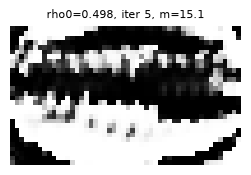

step   6/20  m= 18.3  power=0.6252  ED=0.406  pen=0.3449  J=0.2803
          |g_pow|=1.21e+00  |g_ed|=3.58e-01  scale=8.49e-01  rails= 0.0%  bin=83.1%  grey=0.141
step   7/20  m= 21.6  power=0.7225  ED=0.367  pen=0.4087  J=0.3137
          |g_pow|=1.25e+00  |g_ed|=2.81e-01  scale=1.11e+00  rails= 0.0%  bin=88.9%  grey=0.091
step   8/20  m= 24.8  power=0.7962  ED=0.333  pen=0.2186  J=0.5776
          |g_pow|=6.60e-01  |g_ed|=2.51e-01  scale=6.56e-01  rails= 7.3%  bin=93.7%  grey=0.056
step   9/20  m= 28.1  power=0.8209  ED=0.321  pen=0.2244  J=0.5965
          |g_pow|=6.00e-01  |g_ed|=2.14e-01  scale=7.00e-01  rails=34.5%  bin=95.7%  grey=0.037
step  10/20  m= 31.4  power=0.8391  ED=0.319  pen=0.2706  J=0.5685
          |g_pow|=6.32e-01  |g_ed|=1.87e-01  scale=8.47e-01  rails=48.9%  bin=97.0%  grey=0.024
      -> thresholded re-sim: relaxed=0.8391  binarized=0.8449  gap=-0.59 pts


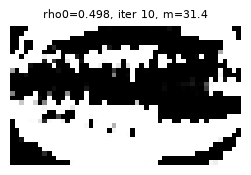

step  11/20  m= 34.6  power=0.8574  ED=0.317  pen=0.1189  J=0.7384
          |g_pow|=3.01e-01  |g_ed|=2.00e-01  scale=3.75e-01  rails=58.9%  bin=97.9%  grey=0.016
step  12/20  m= 37.9  power=0.8634  ED=0.317  pen=0.2126  J=0.6509
          |g_pow|=2.91e-01  |g_ed|=1.09e-01  scale=6.71e-01  rails=66.6%  bin=98.5%  grey=0.011
step  13/20  m= 41.2  power=0.8680  ED=0.315  pen=0.0763  J=0.7917
          |g_pow|=1.78e-01  |g_ed|=1.83e-01  scale=2.43e-01  rails=73.9%  bin=98.7%  grey=0.010
step  14/20  m= 44.4  power=0.8664  ED=0.314  pen=0.2080  J=0.6585
          |g_pow|=4.31e-01  |g_ed|=1.63e-01  scale=6.63e-01  rails=78.9%  bin=98.8%  grey=0.007
step  15/20  m= 47.7  power=0.8694  ED=0.314  pen=0.0427  J=0.8267
          |g_pow|=1.21e-01  |g_ed|=2.23e-01  scale=1.36e-01  rails=81.7%  bin=99.1%  grey=0.006
      -> thresholded re-sim: relaxed=0.8694  binarized=0.8612  gap=+0.82 pts


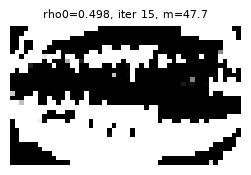

step  16/20  m= 50.9  power=0.8693  ED=0.316  pen=0.1474  J=0.7219
          |g_pow|=2.81e-01  |g_ed|=1.51e-01  scale=4.67e-01  rails=84.9%  bin=99.1%  grey=0.006
step  17/20  m= 54.2  power=0.8733  ED=0.314  pen=0.1446  J=0.7287
          |g_pow|=3.28e-01  |g_ed|=1.78e-01  scale=4.61e-01  rails=86.9%  bin=99.2%  grey=0.006
step  18/20  m= 57.5  power=0.8756  ED=0.314  pen=0.1480  J=0.7276
          |g_pow|=4.47e-01  |g_ed|=2.37e-01  scale=4.71e-01  rails=88.9%  bin=99.2%  grey=0.005
step  19/20  m= 60.7  power=0.8772  ED=0.315  pen=0.1783  J=0.6989
          |g_pow|=4.37e-01  |g_ed|=1.93e-01  scale=5.66e-01  rails=90.1%  bin=99.3%  grey=0.005
step  20/20  m= 64.0  power=0.8780  ED=0.316  pen=0.1990  J=0.6790
          |g_pow|=5.26e-01  |g_ed|=2.09e-01  scale=6.30e-01  rails=91.3%  bin=99.4%  grey=0.005
      -> thresholded re-sim: relaxed=0.8780  binarized=0.8703  gap=+0.77 pts


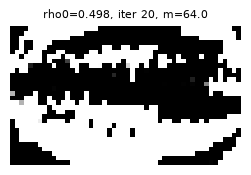


done: {0.498: 'final J = 0.6790'}


In [45]:
from tidy3d.plugins.autograd import adam, apply_updates

# hyperparameters
num_steps = 20            # paper used 50; 20 holds the spend to ~1.1 FlexCredits
learning_rate = 0.05      # see note 2 above -- NOT the upstream 1.0

# paper ramps m LINEARLY from 2 to 64 (Fig. 3, dashed line)
M_LO, M_HI = 2.0, 64.0
m_of = lambda i: M_LO + (M_HI - M_LO) * i / (num_steps - 1)

THRESH_EVERY = 5          # re-simulate the hard-thresholded device this often

# which initial structures to run. rho_inits[:1] is the single cheap run; the paper's fill-fraction
# study needs all three, which triples the cost.
inits_to_run = rho_inits[:1]

results = {}
for rho_init in inits_to_run:
    print(f"\n{'=' * 78}\ninitial structure: uniform rho = {rho_init}\n{'=' * 78}")

    rho = np.full((n_bx, n_by), float(rho_init))
    optimizer = adam(learning_rate=learning_rate)
    opt_state = optimizer.init(rho)

    Js, powers, eds, scales, m_history, snaps, binary_checks = [], [], [], [], [], [], []
    # registered up front, so interrupting the run still leaves the partial history behind
    results[rho_init] = dict(Js=Js, powers=powers, eds=eds, scales=scales,
                             m_history=m_history, snaps=snaps, binary_checks=binary_checks,
                             rho=rho.copy())

    for i in range(num_steps):
        m = m_of(i)
        lo, hi = rho_bounds(m)

        # a rise in m shrinks the admissible range, so re-project rho into it first
        anp.clip(rho, lo, hi, out=rho)

        power, g_power = dJ_power(rho, step_num=i + 1, m=m)   # the FDTD half
        ed, g_ed = dJ_penalty(rho, m=m)                       # free
        value, gradient, scale = combine(power, g_power, ed, g_ed, w_of(i))
        grey = float(grey_indicator(H(rho, m)))

        # -1 sign because Adam minimizes and we are maximizing converted power
        updates, opt_state = optimizer.update(-gradient, opt_state, rho)
        rho[:] = apply_updates(rho, updates)
        anp.clip(rho, lo, hi, out=rho)

        Js.append(value)
        powers.append(power)
        eds.append(ed)
        scales.append(scale)
        m_history.append(m)
        snaps.append(rho.copy())
        results[rho_init]["rho"] = rho.copy()

        at_rails = np.mean((rho <= lo + 1e-12) | (rho >= hi - 1e-12))
        binarized = np.mean((H(rho, m) < 0.05) | (H(rho, m) > 0.95))
        print(f"step {i + 1:>3}/{num_steps}  m={m:>5.1f}  power={power:.4f}  ED={ed:.3f}  "
              f"pen={scale * ed:.4f}  J={value:.4f}\n"
              f"          |g_pow|={np.linalg.norm(g_power):.2e}  |g_ed|={np.linalg.norm(g_ed):.2e}  "
              f"scale={scale:.2e}  rails={at_rails * 100:>4.1f}%  bin={binarized * 100:>4.1f}%  "
              f"grey={grey:.3f}")

        # The number that decides whether the design actually works. A large relaxed-vs-binarized
        # gap means the optimizer is living on gray permittivity or on structure that will not
        # survive the threshold -- which is exactly how the 1-px lamination showed up as an
        # excellent relaxed J last run.
        if (i + 1) % THRESH_EVERY == 0 or i == num_steps - 1:
            bits_now = (rho > 0.5).astype(float)
            p_bin = float(J_power(bits_now, m=m, step_num=f"{i + 1}_binary"))
            binary_checks.append((i + 1, power, p_bin))
            print(f"      -> thresholded re-sim: relaxed={power:.4f}  binarized={p_bin:.4f}  "
                  f"gap={(power - p_bin) * 100:+.2f} pts")

            plt.subplots(figsize=(3, 1.8))
            plt.imshow(np.flipud(1 - H(rho, m).T), cmap="gray", interpolation="nearest")
            plt.title(f"rho0={rho_init}, iter {i + 1}, m={m:.1f}", fontsize=8)
            plt.axis("off")
            plt.show()

print("\ndone:", {kk: f"final J = {v['Js'][-1]:.4f}" for kk, v in results.items()})


In [46]:
# the design carried forward for the field plots at the end of the notebook.
# Selected on transmission, not on J: J now carries the fabrication penalty, so it is not the
# quantity we are trying to compare designs by.
best_init = max(results, key=lambda r: results[r]["powers"][-1])
rho_final = results[best_init]["rho"]
m_final = results[best_init]["m_history"][-1]
print(f"best initial structure: rho = {best_init}  "
      f"(final transmission = {results[best_init]['powers'][-1]:.4f}, "
      f"J = {results[best_init]['Js'][-1]:.4f})")


best initial structure: rho = 0.498  (final transmission = 0.8780, J = 0.6790)


### Results — reproducing the paper's Figs. 3, 4 and 5

The plot below is the analogue of the paper's Fig. 3: fitness against iteration for each initial structure,
with the $m$ ramp on a twin axis. The left panel shows the FOM (which *descends*, like the paper's) and the
right shows the converted power we actually maximize — they are the same run, plotted two ways.

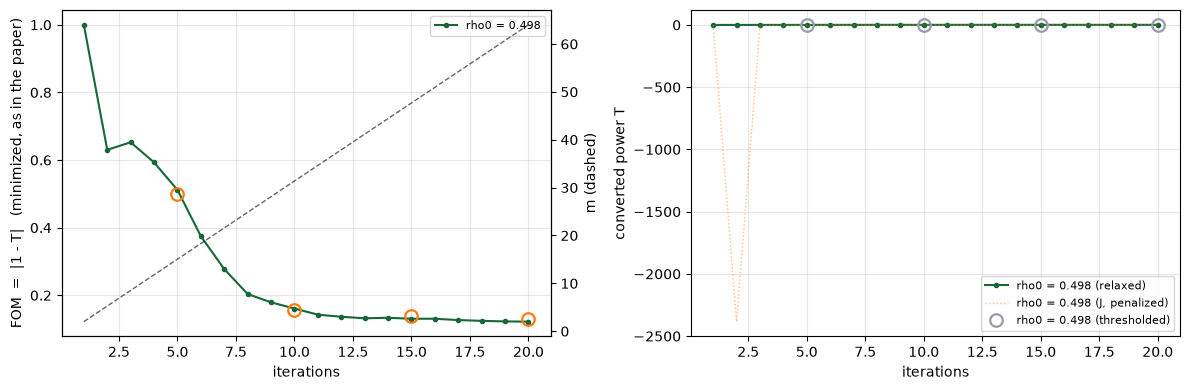

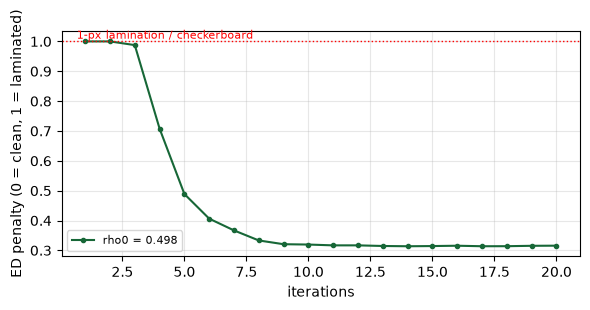

In [47]:
# --- Fig. 3 analogue: fitness vs iteration, with the m ramp -------------------
# Plotted on TRANSMISSION, not on J. J now includes the fabrication penalty, so |1 - J| is not
# the paper's FOM. The binarized checkpoints are overlaid as hollow markers: the gap between the
# solid line and the hollow markers is the only thing that says whether the design is real.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)

for rho_init, r in results.items():
    it = np.arange(1, len(r["powers"]) + 1)
    axL.plot(it, fom(r["powers"]), marker="o", ms=3, label=f"rho0 = {rho_init}")
    axR.plot(it, r["powers"], marker="o", ms=3, label=f"rho0 = {rho_init} (relaxed)")
    axR.plot(it, r["Js"], lw=1, alpha=0.5, ls=":", label=f"rho0 = {rho_init} (J, penalized)")
    if r["binary_checks"]:
        bsteps = [b[0] for b in r["binary_checks"]]
        bvals = [b[2] for b in r["binary_checks"]]
        axR.plot(bsteps, bvals, "o", mfc="none", ms=9, mew=1.6,
                 label=f"rho0 = {rho_init} (thresholded)")
        axL.plot(bsteps, fom(bvals), "o", mfc="none", ms=9, mew=1.6)

axL.set_xlabel("iterations"); axL.set_ylabel("FOM  =  |1 - T|   (minimized, as in the paper)")
axR.set_xlabel("iterations"); axR.set_ylabel("converted power T")
for a in (axL, axR):
    a.grid(alpha=0.3)
axR.legend(loc="lower right", fontsize=8)
axL.legend(loc="upper right", fontsize=8)

# m ramp on a twin axis, matching the paper's dashed line
any_run = next(iter(results.values()))
axM = axL.twinx()
axM.plot(np.arange(1, len(any_run["m_history"]) + 1), any_run["m_history"], "k--", lw=1, alpha=0.6)
axM.set_ylabel("m (dashed)")

plt.show()

# the penalty's own trace, so it is clear whether it ever bit
fig, ax = plt.subplots(figsize=(6, 3), tight_layout=True)
for rho_init, r in results.items():
    ax.plot(np.arange(1, len(r["eds"]) + 1), r["eds"], marker="o", ms=3,
            label=f"rho0 = {rho_init}")
ax.axhline(1.0, color="r", ls=":", lw=1)
ax.text(0.5, 1.0, " 1-px lamination / checkerboard", color="r", fontsize=8, va="bottom")
ax.set_xlabel("iterations"); ax.set_ylabel("ED penalty (0 = clean, 1 = laminated)")
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.show()


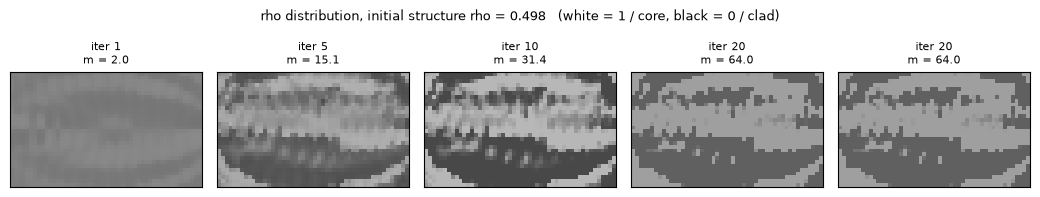

In [48]:
# --- Fig. 4 analogue: evolution of the rho distribution -----------------------
show_init = rho_inits[0] if rho_inits[0] in results else next(iter(results))
r = results[show_init]
picks = [0, 4, 9, 19, 29, len(r["snaps"]) - 1]
picks = [p for p in picks if p < len(r["snaps"])]

fig, axs = plt.subplots(1, len(picks), figsize=(2.1 * len(picks), 2.2), tight_layout=True)
for ax, p in zip(np.atleast_1d(axs), picks):
    ax.imshow(np.flipud(r["snaps"][p].T), cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(f"iter {p + 1}\nm = {r['m_history'][p]:.1f}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"rho distribution, initial structure rho = {show_init}   "
             f"(white = 1 / core, black = 0 / clad)", fontsize=9)
plt.show()

### The paper's headline practical result — does it transfer?

From §3: *"By increasing the value of $\rho$, Si region (white) is greatly increased. Since the difference in
FOMs of $\rho = 0.498,\ 0.7$ is not so large ($\sim 0.01$), the final characteristics are also similar.
**Therefore, we can control the amount of Si in the mosaic region, by changing the initial structure.**"*

That is a genuinely useful knob — it lets you trade fill fraction (and so fabrication robustness) against
almost no performance. Whether it survives the move from AM-FEM to AM-FDTD is the point of this whole run.

The cell below is the Fig. 5 analogue plus the numbers behind it. **If the trend does not reproduce, that is a
real result about the transfer and should be reported as such, not tuned away.**

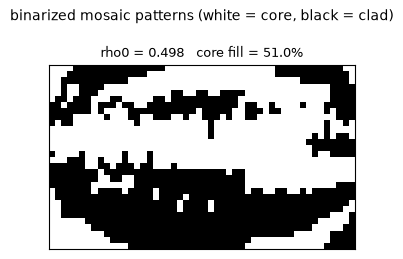

   rho0  core fill %    final T      FOM  still grey %       ED
  0.498        51.0%     0.8780   0.1220          0.6%    0.316

   rho0   ED (binarized)  verdict
  0.498           0.3149  marginal

paper's claim: core fill increases monotonically with initial rho
   observed fills (rho0 ascending): ['51.0%']
   monotonic increasing: True


In [49]:
# --- Fig. 5 analogue: binarized patterns + the Si fill-fraction study ---------
# The paper binarizes at rho = 0.5, where H(0.5) = 0.5 exactly for every m.
bits = {ri: (r["rho"] > 0.5).astype(np.uint8) for ri, r in results.items()}

fig, axs = plt.subplots(1, len(bits), figsize=(4.2 * len(bits), 2.6), tight_layout=True)
for ax, (ri, b) in zip(np.atleast_1d(axs), bits.items()):
    ax.imshow(np.flipud(b.T), cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(f"rho0 = {ri}   core fill = {b.mean() * 100:.1f}%", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("binarized mosaic patterns (white = core, black = clad)", fontsize=10)
plt.show()

print(f"{'rho0':>7} {'core fill %':>12} {'final T':>10} {'FOM':>8} {'still grey %':>13} {'ED':>8}")
for ri, r in results.items():
    Hf = H(r["rho"], r["m_history"][-1])
    grey = np.mean((Hf > 0.05) & (Hf < 0.95))
    print(f"{ri:>7} {bits[ri].mean() * 100:>11.1f}% {r['powers'][-1]:>10.4f} "
          f"{fom(r['powers'][-1]):>8.4f} {grey * 100:>12.1f}% {r['eds'][-1]:>8.3f}")

# ED on the FINAL BINARIZED pattern is the fabrication verdict -- the relaxed ED can look fine
# while the thresholded pattern is laminated.
print(f"\n{'rho0':>7} {'ED (binarized)':>16}  verdict")
for ri in results:
    ed_bin = float(penalty(bits[ri].astype(float)))
    verdict = "clean" if ed_bin < 0.15 else ("marginal" if ed_bin < 0.4 else "LAMINATED")
    print(f"{ri:>7} {ed_bin:>16.4f}  {verdict}")

fills = [bits[ri].mean() for ri in sorted(bits)]
print("\npaper's claim: core fill increases monotonically with initial rho")
print(f"   observed fills (rho0 ascending): {[f'{f * 100:.1f}%' for f in fills]}")
print(f"   monotonic increasing: {all(b >= a for a, b in zip(fills, fills[1:]))}")
if len(results) >= 2:
    ks = sorted(results)
    spread = (max(fom(results[j]['powers'][-1]) for j in ks)
              - min(fom(results[j]['powers'][-1]) for j in ks))
    print(f"   FOM spread across inits: {spread:.4f}"
          f"   (paper reports ~0.01 between rho0 = 0.498 and 0.7)")


### Binarization: the number that actually counts

The optimizer solves a *relaxed* problem — $\rho$ is free to sit anywhere in $[0,1]$, and at $m = 64$ the
permittivity is nearly but not exactly binary. The paper is explicit about this: at iteration 50 *"although
there are many gray regions, the value is almost binarized since $m = 64$."*

A manufacturable device needs each pixel to be exactly core or exactly clad, so the design is hard-thresholded
at $\rho = 0.5$. That threshold is a real perturbation, and the honest way to score it is to **re-simulate**.
The relaxed objective from the loop is *not* the device's performance; the thresholded number is.

If the drop is large, the fix is a longer or steeper $m$ ramp — not quoting the relaxed number.

In [50]:
# A hard bit array is reproduced exactly by feeding rho in {0,1} at any m, since H(0)=0 and H(1)=1.
# This is the headline number: the relaxed transmission is not a device, the thresholded one is.
print(f"{'rho0':>7} {'relaxed T':>11} {'binarized T':>13} {'drop (pts)':>12}")
for ri, r in results.items():
    T_relaxed = r["powers"][-1]
    T_binary = float(J_power(bits[ri].astype(float), m=r["m_history"][-1], verbose=False))
    results[ri]["J_binary"] = T_binary
    print(f"{ri:>7} {T_relaxed:>11.4f} {T_binary:>13.4f} {(T_relaxed - T_binary) * 100:>11.2f}")

best_binary = max(results, key=lambda x: results[x]["J_binary"])
print(f"\nbest thresholded design: rho0 = {best_binary}, "
      f"conversion = {results[best_binary]['J_binary'] * 100:.2f}%")
print(f"upstream Autograd3InverseDesign reports 95.98% -- but that is a RELAXED number at "
      f"beta = 20 (~m = 16),\nnever re-simulated thresholded, so it is a softer bar than it looks.")


   rho0   relaxed T   binarized T   drop (pts)
  0.498      0.8780        0.8703        0.77

best thresholded design: rho0 = 0.498, conversion = 87.03%
upstream Autograd3InverseDesign reports 95.98% -- but that is a RELAXED number at beta = 20 (~m = 16),
never re-simulated thresholded, so it is a softer bar than it looks.


In [51]:
# --- bit-array export -----------------------------------------------------------
# Copied verbatim from hybrid_rotator_90.ipynb so a design stores as a single integer.
def number_to_bits(n: int, num_bits: int) -> np.ndarray:
    bit_string = format(n, f"0{num_bits}b")  # MSB-first, zero-padded to num_bits
    return np.array(list(bit_string), dtype=np.uint8)


def bits_to_number(bits_arr: np.ndarray) -> int:
    bit_string = "".join(bits_arr.astype(str))
    return int(bit_string, 2)


# Bridge to create_hybrid_rotator_90's flat ordering. That function loops i over y DESCENDING
# from +width/2, then j over x ascending; our array is [ix, iy] with y ascending. Hence the flip.
def to_bitstring(bits_2d: np.ndarray) -> np.ndarray:
    """(n_bx, n_by) indexed [x asc, y asc] -> flat, in create_hybrid_rotator_90 order."""
    return np.flip(bits_2d, axis=1).T.ravel().astype(np.uint8)


def from_bitstring(flat: np.ndarray, nbx: int, nby: int) -> np.ndarray:
    return np.flip(np.asarray(flat).reshape(nby, nbx).T, axis=1)


chosen = bits[best_binary]
flat = to_bitstring(chosen)
design_number = bits_to_number(flat)

assert np.array_equal(from_bitstring(flat, n_bx, n_by), chosen), "bitstring round-trip failed"
assert np.array_equal(number_to_bits(design_number, n_pixels), flat), "integer round-trip failed"
print(f"{n_pixels} pixels, first 20 bits: {flat[:20]}")
print("round-trips: 2D <-> flat OK, flat <-> integer OK")
print(f"\ndesign as a single integer:\n{design_number}")

np.save("mosaic_amfdtd_bits.npy", flat)

1500 pixels, first 20 bits: [1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
round-trips: 2D <-> flat OK, flat <-> integer OK

design as a single integer:
32882562627885652984450700041876527479592568008707259869726541860355880626580147818170371970079251803600227372525416421182209601811433060801029385271600668213915100254180597516823274581907794473021401620760397255337898218970207242963306927103491971680571967073588131784940679517771260332014554563029552691410174025251442491623396024347900030073814428644236956906902220741628485752738442626951872143428154539763983954570399801337774016836356189167288288


We then will visualize the final structure, so we convert it to a
regular `Simulation` using the final permittivity values and plot it.

In [52]:
# the THRESHOLDED design, not the relaxed one -- this is the device you would fabricate
sim_final = make_sim(bits[best_binary].astype(float), m=results[best_binary]["m_history"][-1])

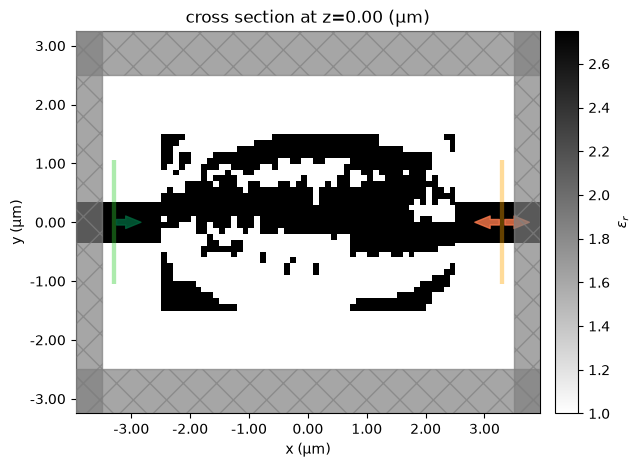

In [53]:
sim_final.plot_eps(z=0, freq=freq0)
plt.show()

Finally, we want to inspect the fields, so we add a field monitor to the
`Simulation` and perform one more run to record the field values for
plotting.

In [54]:
field_mnt = td.FieldMonitor(
    size=(td.inf, td.inf, 0),
    freqs=[freq0],
    name="field_mnt",
)

sim_final = sim_final.copy(update=dict(monitors=(field_mnt, measurement_monitor)))

In [55]:
sim_data_final = web.run(sim_final, task_name="mosaic_amfdtd_final")

16:30:11 SE Asia Standard Time Created task 'mosaic_amfdtd_final' with          
                               resource_id                                      
                               'fdve-df33a857-e6e5-4a09-9bab-a8f29f1b37dd' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=15279105;https://tidy3d.simulation.cloud/workbench?taskId=fdve-df33a857-e6e5-4a09-9bab-a8f29f1b37dd\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=15279106;https://tidy3d.simulation.cloud/workbench?taskId=fdve-df33a857-e6e5-4a09-9bab-a8f29f1b37dd\taskId]8;;\
                               ]8;id=15279105;https://tidy3d.simulation.cloud/workbench?taskId=fdve-df33a857-e6e5-4a09-9bab-a8f29f1b37dd\=]8;;\]8;id=15279107;https://tidy3d.simulation.cloud/workbench?taskId=fdve-df33a857-e6e5-4a09-9bab-a8f29f1b37dd\fdve]8;;\]8;id=15279105;https://tidy3d.simulation.cloud/workbench?taskId=fdve-df33a857-e6e5-4a09-9bab-a8f29f1b37dd\-df33a857-e6e5-4a09-9bab-a8f29f1b37dd']8;;\.

                               Task folder: ]8;id=15279109;https://tidy3d.simulation.cloud/folders/folder-0115173b-c38d-46ac-ae26-956a6110dbd7\'default']8;;\.

Output()

16:30:21 SE Asia Standard Time Estimated FlexCredit cost: 0.025. This assumes   
                               the FDTD solver runs for the full simulation     
                               time; if early shutoff is reached, the billed    
                               cost can be lower. Use 'web.real_cost(task_id)'  
                               to get the billed FlexCredit cost after a        
                               simulation run.

...

16:30:36 SE Asia Standard Time early shutoff detected at 12%, exiting.

16:30:37 SE Asia Standard Time status = success

                               View simulation result at                        
                               ]8;id=15279112;https://tidy3d.simulation.cloud/workbench?taskId=fdve-df33a857-e6e5-4a09-9bab-a8f29f1b37dd\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=15279113;https://tidy3d.simulation.cloud/workbench?taskId=fdve-df33a857-e6e5-4a09-9bab-a8f29f1b37dd\taskId]8;;\
                               ]8;id=15279112;https://tidy3d.simulation.cloud/workbench?taskId=fdve-df33a857-e6e5-4a09-9bab-a8f29f1b37dd\=]8;;\]8;id=15279114;https://tidy3d.simulation.cloud/workbench?taskId=fdve-df33a857-e6e5-4a09-9bab-a8f29f1b37dd\fdve]8;;\]8;id=15279112;https://tidy3d.simulation.cloud/workbench?taskId=fdve-df33a857-e6e5-4a09-9bab-a8f29f1b37dd\-df33a857-e6e5-4a09-9bab-a8f29f1b37dd']8;;\.

Output()

16:30:44 SE Asia Standard Time Loading results from simulation_data.hdf5

We notice that the behavior is as expected and the device performs
exactly how we intended!

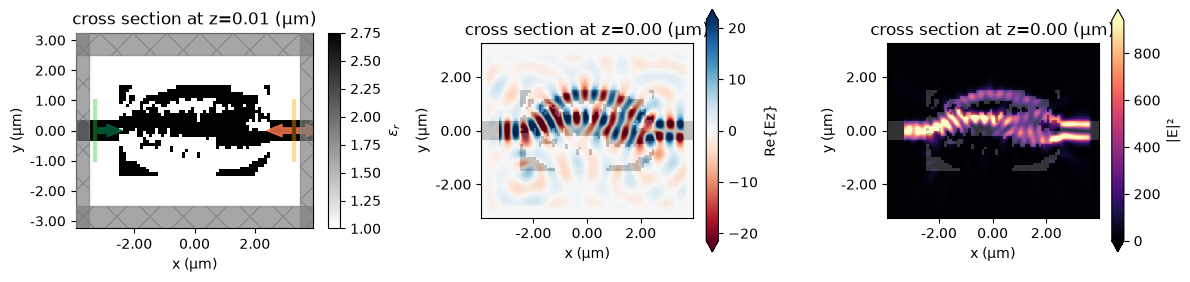

In [56]:
f, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(12, 3), tight_layout=True)
sim_final.plot_eps(z=0.01, freq=freq0, ax=ax0)
ax1 = sim_data_final.plot_field("field_mnt", "Ez", z=0, ax=ax1)
ax2 = sim_data_final.plot_field("field_mnt", "E", "abs^2", z=0, ax=ax2)

The final device converts more than 90% of the input power to the 1st
mode, up from \< 1% when we started.

In [57]:
final_power = (
    sim_data_final["measurement"].amps.sel(direction="+", f=freq0, mode_index=mode_index_out).abs
    ** 2
)
print(f"Final power conversion (thresholded device) = {float(final_power) * 100:.2f}%")
print(f"Core fill fraction = {bits[best_binary].mean() * 100:.1f}%   "
      f"from initial structure rho = {best_binary}")

Final power conversion (thresholded device) = 87.03%
Core fill fraction = 51.0%   from initial structure rho = 0.498


## Export to GDS

The `Simulation` object has the
[.to_gds_file](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Simulation.html#tidy3d.Simulation.to_gds_file)
convenience function to export the final design to a `GDS` file. In
addition to a file name, it is necessary to set a cross-sectional plane
(`z = 0` in this case) on which to evaluate the geometry, a `frequency`
to evaluate the permittivity, and a `permittivity_threshold` to define
the shape boundaries in custom mediums. See the [GDS
export](https://www.flexcompute.com/tidy3d/examples/notebooks/GDSExport/)
notebook for a detailed example on using `.to_gds_file` and other GDS
related functions.

In [58]:
import os

os.makedirs("./misc", exist_ok=True)
sim_final.to_gds_file(
    fname="./misc/mosaic_amfdtd_mode_conv.gds",
    z=0,
    frequency=freq0,
    permittivity_threshold=0.5 * (eps_clad + eps_core),
)